<a href="https://colab.research.google.com/github/RPAlbuquerque/gsdm-spatial-ai/blob/main/from_mobility_intensity_to_market_infrastructure_spatial_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Mobility Intensity to Market Infrastructure
## A Spatial AI Framework for Recovering Hidden Regime Structure and Multiscale Variation

Authors: Rafael Albuquerque, Jessica Miranda, Sisi Wang and Vinícius Brei.

First submission for the I-GUIDE Spatial AI Challenge 2026

# 1 Introduction

## 1.1 Motivation
**This study introduced a Spatial AI framework to recover a latent layer of market infrastructure from human mobility patterns**, showing that movement intensity alone did not explain why some places sustained stronger local economic intensity than others. Across cities worldwide, nearby locations often exhibited similar levels of **mobility intensity, which we defined here as the volume of visitation observed in a given place**, while sustaining markedly different levels of commercial and service activity. In this study, we used **local economic intensity** to refer to the concentration of commerce, services, circulation, and built-environment activity associated with ongoing economic presence in a place.

**Places with similar levels of pedestrian activity nevertheless sustained very different levels of commercial and service activity.** These discrepancies suggested that mobility intensity alone did not capture the spatial conditions that allowed local economic intensity to persist over time.

Markets did not emerge from movement alone. They depended on spatial environments that allowed individuals to repeatedly access locations, encounter services, and return over time. From this perspective, the key question was not simply how much movement a place received, but whether movement was organized in ways consistent with repeated access, temporal regularity, and sustained local interaction.

**Our core contribution was to show that mobility data could be used not only to map flows, but also to identify hidden spatial organization associated with the conditions under which markets emerged, persisted, and differentiated across space.** This approach moved the analysis beyond a standard mobility mapping exercise toward the recovery of latent territorial structure.

## 1.2 Conceptual Framework
We approached **market infrastructure** as **the latent spatial organization of access conditions that supported repeated visitation, stable exposure, and sustained local interaction**. We used the term in a specific and cautious sense. We did **not** use it to refer only to visible physical infrastructure, such as roads, utilities, or buildings, and we did **not** use it to denote observed market outcomes directly. Instead, we used it to describe an underlying spatial condition inferred from how mobility was behaviorally organized across places.

This distinction mattered because two locations could exhibit similar levels of movement while differing substantially in visitor diversity, repeat visitation, dwell time, and temporal regularity. Such differences indicated whether mobility merely passed through space or occurred in patterns more consistent with recurring access and persistent interaction.

Rather than focusing exclusively on mobility volume, we examined how visitation behavior was organized across space through multiple signals, including visitor diversity, repeat visitation, dwell time, and temporal stability. Taken together, these signals reflected the capacity of locations to support recurring access and sustained interaction, revealing spatial conditions under which local economic intensity was more likely to persist rather than remain weak, fragmented, or unstable. **In this sense, market infrastructure was meaningful not as a metaphor, but as an analytically inferable spatial condition.**

## 1.3 Research Question
Building on this perspective, we investigated whether **spatial patterns of human mobility revealed a latent form of market infrastructure** and whether this infrastructure helped explain differences in local economic intensity across places.

Specifically, we asked:

**Can a latent form of market infrastructure be identified from spatial patterns of human mobility, and can it explain spatial differences in local economic intensity?**

## 1.4 Analytical Strategy
To address this question, we developed a spatial analytical framework that combined behavioral mobility indicators, dimensionality reduction, spatial regime detection, economic validation, and multiscale reconstruction.

First, we extracted a latent **Market Infrastructure Index (MII)** from the **covariance structure** of mobility indicators using principal component analysis. Here, the covariance structure did not constitute the substantive research question itself; rather, it served as the analytical mechanism through which hidden organization in mobility behavior became empirically observable.

We then analyzed the spatial organization of this index across Brazil’s census tracts and identified territorially differentiated infrastructure regimes. Next, we evaluated how these regimes related to **local economic intensity** using nighttime light emissions as an external proxy.

Finally, we implemented a mass-preserving downscaling procedure to reconstruct infrastructure patterns at a finer spatial resolution, revealing micro-scale fragmentation that remained hidden within aggregated administrative units. **Taken together, this framework went beyond standard mobility mapping by recovering latent structure, identifying territorial regimes, validating their economic relevance, and reconstructing multiscale spatial variation.**

# 2 Data

## 2.1 Data Provenance

The analytical dataset used in this study resulted from a structured preprocessing workflow that transformed large-scale mobility traces into **tract-level infrastructure indicators**.

We organized this workflow into four preprocessing pipelines: **Pipeline A (Mobility)**, which constructed tract-level behavioral indicators; **Pipeline S (Spatial Integration)**, which linked these indicators to official IBGE census tract geometries; **Pipeline V (Validation)**, which evaluated the robustness of the resulting mobility construct; and **Pipeline X (Spatial Structural Regime Modeling)**, which extracted latent infrastructure structure and identified territorially differentiated regimes.

Together, these pipelines produced the consolidated analytical dataset used throughout this study.

## 2.2 Raw Mobility Data

The mobility signals used in this study originated from a large-scale dataset of anonymized mobility traces aggregated across Brazil. To support distributed processing and storage, the provider partitioned the dataset into multiple compressed files, which we later aggregated to the census tract level.

In [ ]:
import pandas as pd

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

mobility_file = "/ocean/projects/cis260037p/shared/data/mobility_data/mobility_merged.csv.gz"

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

mob = pd.read_csv(mobility_file, compression="gzip")

print("Dataset loaded successfully\n")

# ------------------------------------------------------------
# BASIC STRUCTURE
# ------------------------------------------------------------

total_rows = len(mob)
total_columns = len(mob.columns)
unique_sectors = mob["store_id"].nunique()

print("Total mobility records:", total_rows)
print("Total variables:", total_columns)
print("Census tracts with mobility data:", unique_sectors)

# ------------------------------------------------------------
# VARIABLE TABLE
# ------------------------------------------------------------

var_table = pd.DataFrame({
    "Variable": mob.columns,
    "Non-null observations": mob.notna().sum().values,
    "Missing observations": mob.isna().sum().values,
    "Data type": mob.dtypes.values
})

print("\nMobility dataset variables:\n")

display(var_table)

# ------------------------------------------------------------
# SUMMARY STATISTICS (KEY MOBILITY VARIABLES)
# ------------------------------------------------------------

key_vars = [
    "unique",
    "visits",
    "repeat_visitors",
    "new_visitors",
    "dwell_time_mins"
]

print("\nSummary statistics for key mobility indicators:\n")

display(mob[key_vars].describe().round(2))

Dataset loaded successfully

Total mobility records: 34949440
Total variables: 61
Census tracts with mobility data: 436868

Mobility dataset variables:



,Variable,Non-null observations,Missing observations,Data type
0,month_part,34949440,0,object
1,store_id,34949440,0,int64
2,demographics_gender,34949440,0,object
3,demographics_age_range,34949440,0,object
4,demographics_class,34949440,0,object
...,...,...,...,...
56,dow_7_h1,34949440,0,float64
57,dow_7_h2,34949440,0,float64
58,dow_7_h3,34949440,0,float64
59,dow_7_h4,34949440,0,float64



Summary statistics for key mobility indicators:



,unique,visits,repeat_visitors,new_visitors,dwell_time_mins
count,34949440.00,34949440.00,34949440.00,34949440.00,34078173.00
mean,2445.18,10296.74,1612.85,2444.46,57.23
std,8837.33,31905.81,5781.05,8837.53,31.57
min,0.00,0.00,0.00,0.00,1.00
25%,102.28,618.97,76.30,101.14,34.91
50%,504.96,2808.49,362.82,504.85,53.97
75%,1881.81,9408.59,1295.64,1881.80,74.28
max,1429843.67,9432496.36,1110024.66,1429843.67,1075.00


The merged dataset contained **34,949,440 visitation records** across **436,868 census tracts** and captured **substantial heterogeneity** in visitation behavior across space. Variables such as **visits**, **unique visitors**, **repeat visitors**, **new visitors**, and **dwell time** formed the empirical basis for constructing tract-level mobility indicators and recovering the latent infrastructure structure analyzed in this study.

## 2.3 Census Tract Geometries

We defined the spatial units of analysis using the official census tracts established by the **Brazilian Institute of Geography and Statistics (IBGE)** for the 2022 census geography. These units provided a consistent territorial framework for integrating behavioral mobility signals with spatial location.

Census tracts loaded successfully

Total census tracts: 472780
Unique sector IDs: 468099
CRS: EPSG:4674

Columns available:
['CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO', 'AREA_KM2', 'CD_REGIAO', 'NM_REGIAO', 'CD_UF', 'NM_UF', 'CD_MUN', 'NM_MUN', 'CD_DIST', 'NM_DIST', 'CD_SUBDIST', 'NM_SUBDIST', 'CD_BAIRRO', 'NM_BAIRRO', 'CD_NU', 'NM_NU', 'CD_FCU', 'NM_FCU', 'CD_AGLOM', 'NM_AGLOM', 'CD_RGINT', 'NM_RGINT', 'CD_RGI', 'NM_RGI', 'CD_CONCURB', 'NM_CONCURB', 'geometry']


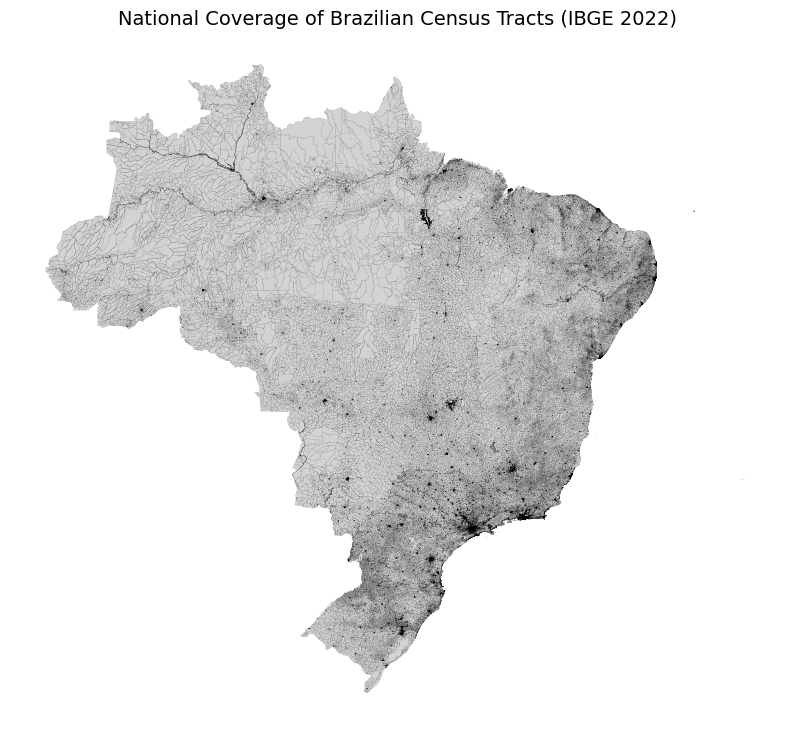

In [ ]:
import geopandas as gpd

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

shapefile_path = "/ocean/projects/cis260037p/shared/data/shapefiles/BR_setores_CD2022.gpkg"

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

tracts = gpd.read_file(shapefile_path)

print("Census tracts loaded successfully\n")

print("Total census tracts:", len(tracts))
print("Unique sector IDs:", tracts["CD_SETOR"].nunique())
print("CRS:", tracts.crs)

print("\nColumns available:")
print(tracts.columns.tolist())
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

tracts.plot(
    ax=ax,
    linewidth=0.05,
    color="lightgrey",
    edgecolor="black"
)

ax.set_axis_off()

ax.set_title(
    "National Coverage of Brazilian Census Tracts (IBGE 2022)",
    fontsize=14
)

plt.show()

The IBGE dataset contained 472,780 census tract geometries and provided complete geographic coverage of Brazil. Because some tract identifiers appeared in multipart or repeated geometric representations, the number of unique sector IDs was 468,099. These geometries served as the spatial backbone of the analysis, allowing us to examine infrastructure patterns across highly diverse metropolitan and rural contexts.

## 2.4 Nighttime Lights Data

To evaluate the economic relevance of mobility-based infrastructure patterns, we used nighttime light emissions as an external proxy for local economic intensity. These data were derived from the Visible Infrared Imaging Radiometer Suite (VIIRS), which measures stable nighttime illumination across the Earth's surface.

In [ ]:
import rasterio
import numpy as np
import os

nightlight_path = "/ocean/projects/cis260037p/shared/data/nightlights"

tiles = sorted([
    f for f in os.listdir(nightlight_path)
    if f.endswith(".tif")
])

print("Number of VIIRS tiles:", len(tiles))

# sample tile
sample_tile = os.path.join(nightlight_path, tiles[0])

with rasterio.open(sample_tile) as src:

    data = src.read(1)

    print("\nTile metadata:")
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)

    print("\nLuminosity statistics:")
    print("Min:", np.nanmin(data))
    print("Max:", np.nanmax(data))
    print("Mean:", np.nanmean(data))

Number of VIIRS tiles: 30

Tile metadata:
Shape: (5601, 17281)
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.00208333335, bottom=51.66458314665, right=-107.99791609064998, top=75.00208333335)

Luminosity statistics:
Min: -1.5
Max: 930.68317
Mean: 0.02460318


The VIIRS dataset consisted of 30 raster tiles containing annual nighttime light intensity measurements. Because nighttime luminosity has been widely used as a proxy for local economic intensity, urbanization, and infrastructure development, we used it as an external benchmark for assessing whether mobility-derived infrastructure patterns aligned with spatial variation in local economic intensity.

## 2.5 Analytical Dataset

The final analytical dataset integrated mobility indicators, census tract geometries, and derived infrastructure metrics into a unified spatial database. Each observation corresponded to a single census tract and included the behavioral mobility indicators and **Market Infrastructure Index (MII)** used throughout the analysis.

In [ ]:
import geopandas as gpd

# ------------------------------------------------------------
# PATH
# ------------------------------------------------------------

analysis_path = "/ocean/projects/cis260037p/shared/data/preprocessed_data/census_tracts_brazil_mobility_mii_clean.gpkg"

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

gdf = gpd.read_file(analysis_path)

print("Analytical dataset loaded successfully\n")

print("Total census tracts:", len(gdf))
print("Unique tract IDs:", gdf["ct_id"].nunique())
print("CRS:", gdf.crs)

print("\nColumns available:")
print(gdf.columns.tolist())
print("Census tracts with mobility data:", gdf["mii"].notna().sum())
print("Census tracts without mobility data:", gdf["mii"].isna().sum())
gdf["mii"].describe().round(3)

Analytical dataset loaded successfully

Total census tracts: 468099
Unique tract IDs: 468099
CRS: EPSG:4674

Columns available:
['ct_id', 'unique', 'visits', 'repeat_visitors', 'new_visitors', 'unique_q1', 'unique_q2', 'unique_q3', 'unique_q4', 'visits_q1', 'visits_q2', 'visits_q3', 'visits_q4', 'repeat_q1', 'repeat_q2', 'repeat_q3', 'repeat_q4', 'new_visitor_q1', 'new_visitor_q2', 'new_visitor_q3', 'new_visitor_q4', 'dwell_time_mins', 'unique_week_mean', 'unique_week_cv', 'visits_week_mean', 'visits_week_cv', 'unique_weeks_sum', 'unique_total_minus_weeks', 'visits_weeks_sum', 'visits_total_minus_weeks', 'log1p_visits_A4', 'log1p_unique_A4', 'log1p_repeat_visitors_A4', 'log1p_new_visitors_A4', 'stability_visits_week_cv_A4', 'stability_unique_week_cv_A4', 'z_dwell_time_mins', 'z_log1p_visits_A4', 'z_log1p_unique_A4', 'z_log1p_repeat_visitors_A4', 'z_log1p_new_visitors_A4', 'z_stability_visits_week_cv_A4', 'z_stability_unique_week_cv_A4', 'mii_zmean_A4', 'mii_pca1_A4', 'z_mii_zmean_A4', 

count    396948.000
mean         -0.027
std           0.875
min          -7.272
25%          -0.093
50%           0.205
75%           0.392
max           1.657
Name: mii, dtype: float64

After spatial integration and harmonization, the final analytical dataset contained **468,099 census tracts**, including **396,948 tracts with observed mobility activity** and **71,151 tracts without measurable visitation signals**. This consolidated dataset formed the empirical foundation for all subsequent analyses.

In [ ]:
# ------------------------------------------------------------
# NORMALIZE MII TO [-1, 1]
# ------------------------------------------------------------

mii_min = gdf["mii"].min()
mii_max = gdf["mii"].max()

gdf["mii_norm"] = 2 * (gdf["mii"] - mii_min) / (mii_max - mii_min) - 1

print("Original MII range:")
print("Min:", gdf["mii"].min())
print("Max:", gdf["mii"].max())

print("\nNormalized MII range:")
print("Min:", gdf["mii_norm"].min())
print("Max:", gdf["mii_norm"].max())
gdf["mii_norm"].describe().round(3)
output_path = "/ocean/projects/cis260037p/shared/data/preprocessed_data/census_tracts_brazil_mii_normalized.gpkg"

gdf.to_file(output_path, driver="GPKG")

print("Dataset saved with normalized MII")

Original MII range:
Min: -7.271697051910064
Max: 1.6566794308497006

Normalized MII range:
Min: -1.0
Max: 1.0
Dataset saved with normalized MII


To facilitate interpretation and visualization, we rescaled the **Market Infrastructure Index (MII)** to a normalized range between **−1 and 1** using a min–max transformation. This normalization preserved the relative ordering of census tracts while placing the index on a standardized scale. We retained the original MII values for statistical analyses and used the normalized version primarily for visualization in subsequent spatial sections.

# 3 Behavioral Structure of Mobility

## 3.1 Mobility Indicators

We characterized human mobility behavior using a set of complementary indicators that capture **visitation intensity**, **visitor diversity**, **repeat visitation patterns**, and **temporal stability**.

These indicators included measures of total visits, unique visitors, repeat visitors, new visitors, average dwell time, and weekly stability in visitation patterns. Together, they described how individuals interacted with places across space and provided the empirical basis for identifying latent infrastructure structures reflected in mobility behavior.

In [ ]:
mobility_vars = [
    "z_log1p_visits_A4",
    "z_log1p_unique_A4",
    "z_log1p_repeat_visitors_A4",
    "z_log1p_new_visitors_A4",
    "z_dwell_time_mins",
    "z_stability_unique_week_cv_A4",
    "z_stability_visits_week_cv_A4"
]

gdf[mobility_vars].describe().round(2)

,z_log1p_visits_A4,z_log1p_unique_A4,z_log1p_repeat_visitors_A4,z_log1p_new_visitors_A4,z_dwell_time_mins,z_stability_unique_week_cv_A4,z_stability_visits_week_cv_A4
count,396948.00,396948.00,396948.00,396948.00,387858.00,387890.00,387890.00
mean,0.02,0.01,0.02,0.02,0.01,0.02,0.01
std,0.98,0.98,0.98,0.98,0.99,0.96,0.96
min,-4.85,-4.43,-4.37,-3.57,-1.78,-14.97,-14.25
25%,-0.21,-0.33,-0.30,-0.20,-0.69,-0.00,-0.01
50%,0.22,0.18,0.19,0.22,-0.09,0.24,0.22
75%,0.54,0.60,0.59,0.56,0.54,0.39,0.38
max,2.62,2.69,2.77,2.27,32.24,0.77,1.00


The descriptive statistics showed **substantial heterogeneity** in mobility activity across census tracts. After applying log(1 + x) transformations and **z-score standardization**, the indicators captured relative differences in visitation intensity, visitor diversity, repeat visitation behavior, dwell time, and temporal stability on a comparable scale. These variables provided a **multidimensional representation of mobility behavior** and formed the basis for the subsequent covariance analyses.

## 3.2 Correlation Structure

We next examined the correlation structure among the standardized mobility indicators to assess whether these variables captured related dimensions of a broader behavioral pattern.

If multiple indicators moved together systematically, their correlations would suggest the presence of an underlying structure organizing visitation activity across space.

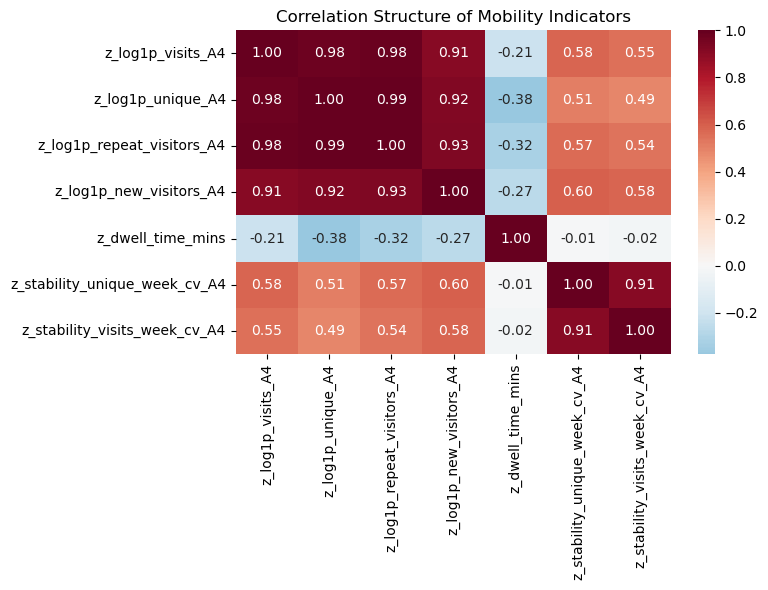

In [ ]:
corr = gdf[mobility_vars].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Structure of Mobility Indicators")

plt.tight_layout()

plt.show()

The correlation matrix revealed **strong associations** among several standardized mobility indicators, especially among measures of visitation intensity, visitor diversity, and repeat visitation. These patterns suggested that the indicators captured related aspects of a broader behavioral structure rather than isolated dimensions of mobility activity. Because the variables had already been log-transformed and standardized, these correlations reflected **structural relationships among mobility signals** rather than differences in measurement scale.

## 3.3 Evidence of Latent Behavioral Structure

The strong correlations observed among the standardized mobility indicators suggested that these variables captured related aspects of a common behavioral phenomenon.

Rather than representing independent signals, visitation intensity, visitor diversity, repeat visitation behavior, dwell time, and temporal stability appeared to reflect a shared underlying structure governing how locations attracted and sustained human mobility across space.

To evaluate whether such a latent structure existed, we first examined the covariance structure of these indicators using an exploratory principal component analysis (PCA). This step served as a diagnostic assessment of whether the mobility indicators exhibited a dominant common dimension before the formal construction of the Market Infrastructure Index (MII) in Section 4.

If a strong first component emerged, it would indicate the presence of an underlying structural dimension organizing mobility behavior across locations.

Because the mobility indicators were analyzed in standardized form at this exploratory stage, the extracted components captured structural relationships among behavioral signals rather than differences in measurement scale.

Explained variance by component:
[0.68  0.181 0.102 0.02  0.014 0.002 0.001]


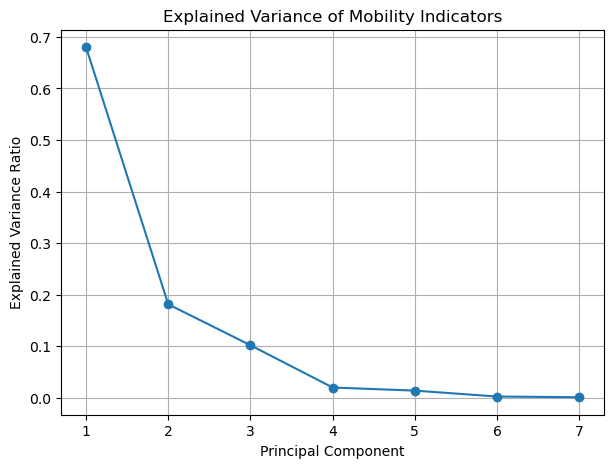

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# ------------------------------------------------------------
# Select mobility indicators
# ------------------------------------------------------------

X = gdf[mobility_vars].dropna()

# ------------------------------------------------------------
# Standardize variables
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Run PCA
# ------------------------------------------------------------

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance by component:")
print(np.round(explained_variance,3))

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

components = range(1, len(explained_variance) + 1)

plt.plot(
    components,
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Explained Variance of Mobility Indicators")

plt.xticks(components)

plt.grid(True)

plt.show()



The exploratory PCA revealed a highly structured covariance pattern among the mobility indicators. The first principal component explained 68.0% of the total variance, indicating that the mobility indicators exhibited a strong common dimension at the exploratory stage. The remaining components accounted for progressively smaller shares of variance, showing that a large portion of the mobility system could be summarized by a single latent dimension.

This dominant component reflected the joint alignment of visitation intensity, visitor diversity, repeat visitation patterns, dwell time, and temporal stability. These exploratory results provided diagnostic evidence that the indicators shared a common structural dimension, thereby motivating the formal construction of the Market Infrastructure Index (MII) in the next section.

# 4 Construction of the Market Infrastructure Index

## 4.1 Indicator Standardization

To construct the **Market Infrastructure Index (MII)**, we first standardized the mobility indicators to ensure comparability across variables measured on different scales.

Standardization removed differences in magnitude and variance among indicators, allowing each variable to contribute proportionally to the covariance structure analyzed through principal component analysis.

In the analytical dataset used in this study, the mobility indicators had already been transformed using log(1 + x) and standardized using z-score normalization during preprocessing. As a result, the variables used in the PCA already represented standardized behavioral signals of mobility activity. Building on the exploratory diagnostic evidence presented in Section 3, we then applied PCA formally to construct the Market Infrastructure Index (MII). The results reported in this section therefore correspond to the formal component extraction used to define the final index.

In [ ]:
from sklearn.preprocessing import StandardScaler

X = gdf[mobility_vars].dropna()

X_scaled = gdf[mobility_vars].dropna().values


print("Number of observations used in PCA:", X_scaled.shape[0])
print("Number of variables:", X_scaled.shape[1])

Number of observations used in PCA: 387779
Number of variables: 7


## 4.2 Principal Component Extraction

We applied principal component analysis (PCA) to the standardized mobility indicators to formally extract the dominant covariance structure used to define the Market Infrastructure Index (MII) across census tracts.


PCA decomposed the covariance matrix of the indicators into orthogonal components ranked according to the proportion of variance they explained. The first component captured the strongest common variation among the indicators and represented the dominant behavioral dimension underlying mobility activity.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

components = pca.components_

explained = pca.explained_variance_ratio_

print("Explained variance:")
print(explained)

Explained variance:
[0.62211828 0.22400709 0.11592642 0.01815565 0.01754334 0.00151373
 0.0007355 ]


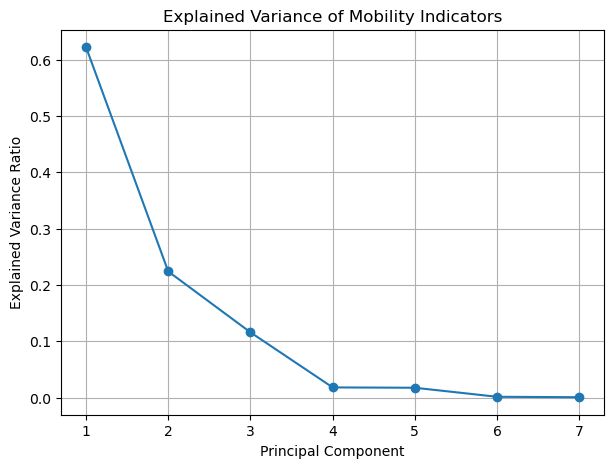

In [ ]:
import matplotlib.pyplot as plt

components = range(1, len(explained) + 1)

plt.figure(figsize=(7,5))

plt.plot(
    components,
    explained,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Explained Variance of Mobility Indicators")

plt.xticks(components)

plt.grid(True)

plt.show()

Because some census tracts contained missing values for specific mobility indicators, we estimated the PCA on the subset of tracts with complete observations across all indicators. The results confirmed a **dominant first component**, which summarized the main covariance structure among visitation intensity, visitor diversity, repeat visitation patterns, dwell time, and temporal stability. This component provided the empirical basis for constructing the **Market Infrastructure Index (MII)**.

## 4.3 Component Loadings

To interpret the behavioral dimension extracted by PCA, we examined the loadings of the first principal component.

Loadings indicated the extent to which each mobility indicator contributed to the latent dimension captured by the component. Indicators with larger absolute loadings exerted greater influence on the extracted structure and played a stronger role in defining the dominant behavioral pattern.

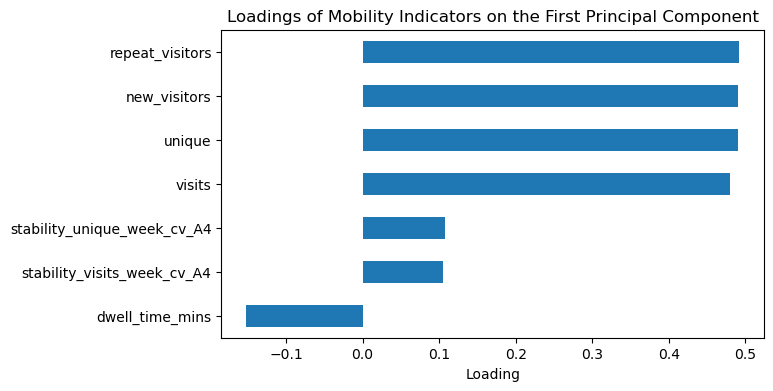

In [ ]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=mobility_vars,
    columns=[f"PC{i+1}" for i in range(len(mobility_vars))]
)

loadings

import matplotlib.pyplot as plt

loadings["PC1"].sort_values().plot(
    kind="barh",
    figsize=(7,4)
)

plt.title("Loadings of Mobility Indicators on the First Principal Component")

plt.xlabel("Loading")

plt.show()

The loadings of the first principal component showed that indicators capturing **visitation intensity**, **visitor diversity**, and **repeat visitation** contributed strongly to the dominant behavioral dimension. The temporal stability indicators also contributed meaningfully, highlighting the role of consistent visitation dynamics in supporting stable mobility activity. Taken together, these patterns showed that the first principal component captured a **shared structural dimension** associated with recurring and sustained mobility behavior across locations.

## 4.4 Definition of the Market Infrastructure Index

We defined the **Market Infrastructure Index (MII)** as the first principal component extracted from the standardized mobility indicators.

Formally, the index was a weighted linear combination of the mobility indicators, with weights given by the loadings of the first principal component.

Because the first component captured the dominant covariance structure among visitation signals, the resulting index summarized the **mobility conditions associated with repeated access, stable visitation, and sustained local interaction**. Higher index values corresponded to locations with stronger and more stable visitation dynamics, whereas lower values indicated weaker or less organized mobility activity.

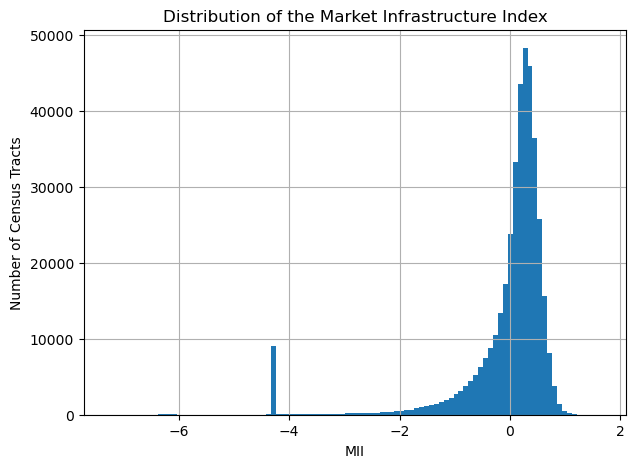

In [ ]:
plt.figure(figsize=(7,5))

gdf["mii"].hist(
    bins=100
)

plt.title("Distribution of the Market Infrastructure Index")

plt.xlabel("MII")

plt.ylabel("Number of Census Tracts")

plt.show()

## 4.5 Analytical Dataset

The final analytical dataset integrated the outputs of the preprocessing pipelines into a unified spatial database covering the entire national territory.

This dataset combined census tract geometries with mobility indicators and derived infrastructure metrics, ensuring that each observation corresponded to a single census tract with its associated behavioral and spatial attributes.

In [ ]:
gdf = gpd.read_file(
    "/ocean/projects/cis260037p/shared/data/preprocessed_data/census_tracts_brazil_mobility_mii_clean.gpkg"
)

print("Analytical dataset loaded successfully\n")

print("Total census tracts:", len(gdf))
print("Unique tract IDs:", gdf["ct_id"].nunique())

print("\nCRS:", gdf.crs)

print("\nColumns available:")
print(list(gdf.columns))

Analytical dataset loaded successfully

Total census tracts: 468099
Unique tract IDs: 468099

CRS: EPSG:4674

Columns available:
['ct_id', 'unique', 'visits', 'repeat_visitors', 'new_visitors', 'unique_q1', 'unique_q2', 'unique_q3', 'unique_q4', 'visits_q1', 'visits_q2', 'visits_q3', 'visits_q4', 'repeat_q1', 'repeat_q2', 'repeat_q3', 'repeat_q4', 'new_visitor_q1', 'new_visitor_q2', 'new_visitor_q3', 'new_visitor_q4', 'dwell_time_mins', 'unique_week_mean', 'unique_week_cv', 'visits_week_mean', 'visits_week_cv', 'unique_weeks_sum', 'unique_total_minus_weeks', 'visits_weeks_sum', 'visits_total_minus_weeks', 'log1p_visits_A4', 'log1p_unique_A4', 'log1p_repeat_visitors_A4', 'log1p_new_visitors_A4', 'stability_visits_week_cv_A4', 'stability_unique_week_cv_A4', 'z_dwell_time_mins', 'z_log1p_visits_A4', 'z_log1p_unique_A4', 'z_log1p_repeat_visitors_A4', 'z_log1p_new_visitors_A4', 'z_stability_visits_week_cv_A4', 'z_stability_unique_week_cv_A4', 'mii_zmean_A4', 'mii_pca1_A4', 'z_mii_zmean_A4',

The final analytical dataset contained **468,099 census tracts** and preserved complete national geographic coverage. In addition to the full set of behavioral mobility indicators, it included the **Market Infrastructure Index (MII)** derived from the covariance structure of visitation behavior. This consolidated geospatial base served as the empirical foundation for all subsequent analyses in the study.

# 5 Spatial Distribution of Market Infrastructure

## 5.1 National Spatial Distribution

Having constructed the **Market Infrastructure Index (MII)**, we next examined how this dimension was distributed across geographic space.

Because the index summarized the covariance structure of mobility behavior across census tracts, its spatial distribution revealed where mobility-based infrastructure was relatively strong or weak nationwide.

In [ ]:
# ---------------------------------------------------------
# Reproject geometry to metric CRS for spatial analysis
# ---------------------------------------------------------

gdf = gdf.to_crs(5880)

print("New CRS:", gdf.crs)

New CRS: EPSG:5880


In [ ]:
# ---------------------------------------------------------
# Mobility indicators used in GW-PCA
# ---------------------------------------------------------

mobility_vars = [
    "z_log1p_visits_A4",
    "z_log1p_unique_A4",
    "z_log1p_repeat_visitors_A4",
    "z_log1p_new_visitors_A4",
    "z_dwell_time_mins",
    "z_stability_unique_week_cv_A4",
    "z_stability_visits_week_cv_A4"
]

X = gdf[mobility_vars].dropna().values

print("Observations used:", X.shape[0])
print("Variables:", X.shape[1])

Observations used: 387779
Variables: 7


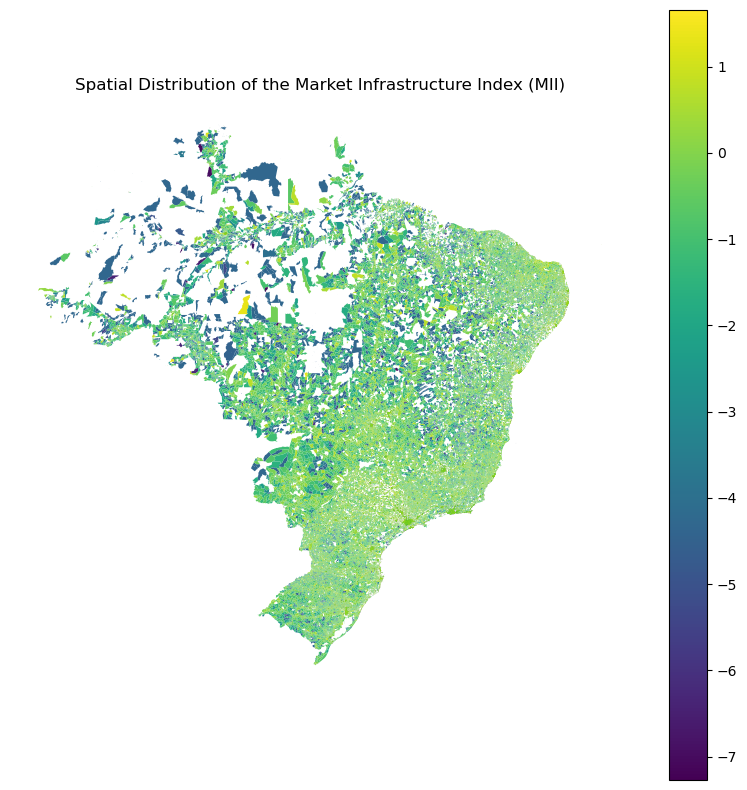

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    column="mii",
    cmap="viridis",
    linewidth=0,
    ax=ax,
    legend=True
)

ax.set_title("Spatial Distribution of the Market Infrastructure Index (MII)")

ax.set_axis_off()

plt.show()

Mapping the **Market Infrastructure Index (MII)** across Brazil allowed us to visualize the spatial organization of mobility-based infrastructure and identify broad territorial patterns in the conditions associated with recurring visitation and sustained mobility activity.

## 5.2 Distribution Across the Territory

The spatial distribution of the **Market Infrastructure Index** revealed substantial geographic heterogeneity in the organization of mobility-based infrastructure across Brazil.

High-index regions clustered around major metropolitan areas, transportation corridors, and economically active urban centers, where visitation patterns were more intense, diverse, and stable. In contrast, large portions of the national territory exhibited relatively low index values, indicating weaker or less structured mobility patterns. Taken together, these results highlighted the **uneven territorial distribution** of mobility-based infrastructure across the country.

# 6 Mobility Infrastructure Regimes

## 6.1 Mobility Infrastructure Regimes

The national infrastructure field identified in the previous sections did not vary only as a continuous surface. In addition to spatial gradients in infrastructure intensity, the organization of mobility behavior also exhibited **spatially differentiated covariance structures**.

To recover these localized structures, we implemented a spatially localized PCA procedure over K-nearest-neighbor neighborhoods. This approach relaxed the assumption of spatial stationarity by allowing covariance relationships among mobility indicators to vary across geographic space.

Rather than estimating covariance globally, the procedure computed localized principal components at each focal location, producing a spatially varying representation of the organization of mobility infrastructure. We then discretized this localized covariance field by clustering observations in the two-dimensional space defined by the first two local principal components.

Using **k-means clustering with k = 4**, we identified four mobility infrastructure regimes capturing distinct configurations of visitation dynamics across space.

In [ ]:
# ============================================================
# SECTION 6 — Mobility Infrastructure Regimes
# ============================================================

import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

print("▶️ Preparing mobility infrastructure regime analysis")

# ------------------------------------------------------------
# Mobility variables
# ------------------------------------------------------------

mobility_vars = [
    "z_log1p_visits_A4",
    "z_log1p_unique_A4",
    "z_log1p_repeat_visitors_A4",
    "z_log1p_new_visitors_A4",
    "z_dwell_time_mins",
    "z_stability_unique_week_cv_A4",
    "z_stability_visits_week_cv_A4"
]


# ------------------------------------------------------------
# Remove missing observations
# ------------------------------------------------------------

gdf_valid = gdf.dropna(subset=mobility_vars).copy()

print("Valid tracts:", len(gdf_valid))


# ------------------------------------------------------------
# Spatial coordinates
# ------------------------------------------------------------

coords = np.column_stack([
    gdf_valid.geometry.centroid.x,
    gdf_valid.geometry.centroid.y
])

print("Coordinate matrix:", coords.shape)


# ------------------------------------------------------------
# Mobility matrix
# ------------------------------------------------------------

X = gdf_valid[mobility_vars].values

print("Mobility matrix:", X.shape)


# ------------------------------------------------------------
# Build spatial neighbors
# ------------------------------------------------------------

print("▶️ Building spatial neighbor structure")

K_NEIGHBORS = 200

nbrs = NearestNeighbors(
    n_neighbors=K_NEIGHBORS,
    algorithm="ball_tree"
).fit(coords)

distances, indices = nbrs.kneighbors(coords)

print("Neighbor matrix:", indices.shape)


# ------------------------------------------------------------
# Local PCA over K-nearest-neighbor neighborhoods
# ------------------------------------------------------------

print("▶️ Running local PCA")

pc1_local = np.zeros(len(gdf_valid))
pc2_local = np.zeros(len(gdf_valid))

for i in range(len(gdf_valid)):

    neigh_idx = indices[i]

    X_local = X[neigh_idx]

    pca = PCA(n_components=2)
    pca.fit(X_local)

    pc1_local[i] = pca.components_[0,0]
    pc2_local[i] = pca.components_[1,0]


# ------------------------------------------------------------
# Save local components
# ------------------------------------------------------------

gdf_valid["PC1_local"] = pc1_local
gdf_valid["PC2_local"] = pc2_local

print("✔ Local principal components created")


# ------------------------------------------------------------
# K-means clustering (4 regimes)
# ------------------------------------------------------------

print("▶️ Identifying mobility infrastructure regimes")

X_cluster = gdf_valid[["PC1_local", "PC2_local"]]

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_cluster)

gdf_valid["infrastructure_regime"] = clusters

print("✔ Regimes created successfully")


# ------------------------------------------------------------
# Merge regimes back to full dataset
# ------------------------------------------------------------

gdf = gdf.merge(
    gdf_valid[["ct_id", "PC1_local", "PC2_local", "infrastructure_regime"]],
    on="ct_id",
    how="left"
)

print("✔ Regimes merged into main dataset")

▶️ Preparing mobility infrastructure regime analysis
Valid tracts: 387779
Coordinate matrix: (387779, 2)
Mobility matrix: (387779, 7)
▶️ Building spatial neighbor structure
Neighbor matrix: (387779, 200)
▶️ Running local PCA
✔ Local principal components created
▶️ Identifying mobility infrastructure regimes
✔ Regimes created successfully
✔ Regimes merged into main dataset


The local PCA procedure generated a **spatially varying covariance field** across 387,779 valid tracts, and the clustering step assigned each tract to one of **four mobility infrastructure regimes**. This procedure provided the basis for examining how structurally distinct mobility environments varied across the national territory.

## 6.2 Regime Characteristics

After identifying infrastructure regimes via unsupervised clustering, we examined the behavioral characteristics of each regime.

To interpret the meaning of these clusters, we computed the average values of the mobility indicators within each regime. These averages allowed us to compare how visitation intensity, visitor diversity, repeat visitation, dwell time, and temporal stability differed across infrastructural environments.

In [ ]:
gdf.groupby("infrastructure_regime")[mobility_vars].mean().round(2)

,z_log1p_visits_A4,z_log1p_unique_A4,z_log1p_repeat_visitors_A4,z_log1p_new_visitors_A4,z_dwell_time_mins,z_stability_unique_week_cv_A4,z_stability_visits_week_cv_A4
infrastructure_regime,,,,,,,
0.0,-0.20,-0.29,-0.27,-0.28,0.15,-0.12,-0.09
1.0,0.44,0.50,0.48,0.47,-0.16,0.25,0.23
2.0,-0.34,-0.47,-0.45,-0.51,0.37,-0.49,-0.47
3.0,0.13,0.12,0.12,0.12,-0.13,0.10,0.10


The regime-level averages revealed **clear structural differences** in mobility behavior across census tracts. Some regimes exhibited higher visitation intensity, greater visitor diversity, and greater temporal stability, whereas others reflected weaker or less organized mobility patterns. Taken together, these profiles showed that mobility-based infrastructure varied not only in magnitude, but also in **behavioral configuration** across space.

## 6.3 Spatial Distribution of Infrastructure Regimes

Having identified four mobility infrastructure regimes, we next examined their distribution across the national territory.

Mapping the regimes allowed us to observe whether distinct mobility environments clustered geographically and whether specific infrastructural configurations appeared systematically in metropolitan, regional, or low-activity areas.

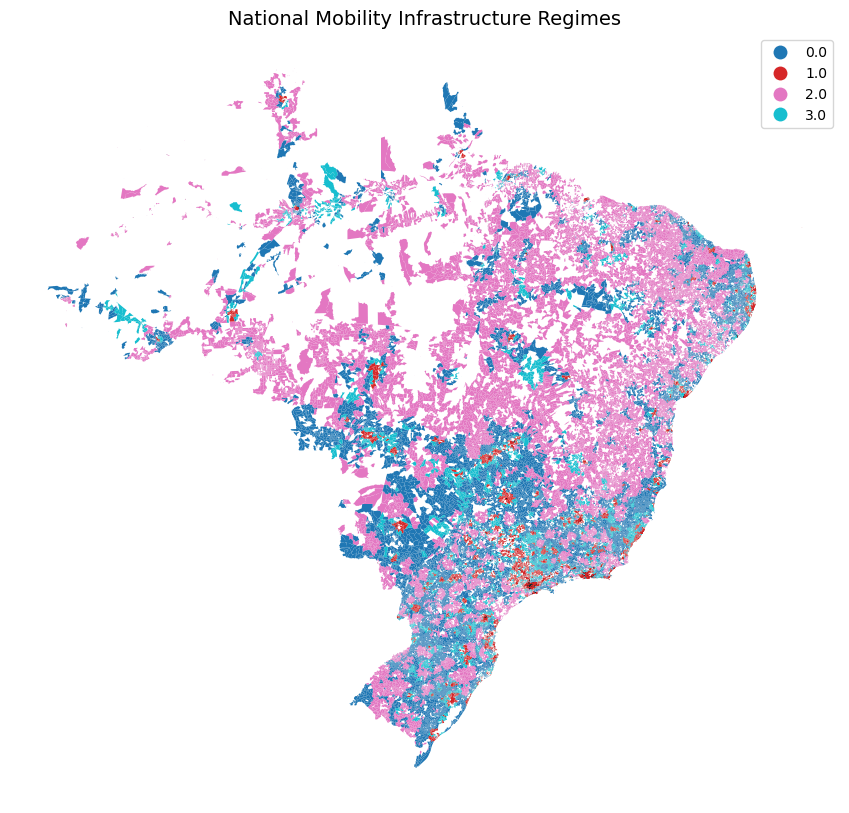

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,10))

gdf.plot(
    column="infrastructure_regime",
    categorical=True,
    cmap="tab10",
    linewidth=0,
    ax=ax,
    legend=True
)

ax.set_title("National Mobility Infrastructure Regimes", fontsize=14)

ax.set_axis_off()

plt.show()

The national distribution of regimes revealed **clear territorial organization** in mobility-based infrastructure across Brazil. More developed regimes clustered around major metropolitan areas and economically active corridors, whereas lower-intensity regimes dominated large portions of sparsely populated regions. These patterns showed that mobility infrastructure formed **territorially structured environments** rather than a uniform geography of movement.

## 6.4 Spatial Autocorrelation of Infrastructure Regimes

To evaluate whether mobility infrastructure regimes exhibited spatial clustering, we computed **Moran’s I** using **Queen contiguity spatial weights**.

Moran’s I was used to measure the degree of spatial autocorrelation in the distribution of regimes across census tracts. Positive values indicated that similar regimes tended to cluster geographically, whereas values near zero would indicate spatial randomness.

In [ ]:
from libpysal.weights import Queen
from esda.moran import Moran

print("▶️ Computing Moran's I for infrastructure regimes")
print("-"*60)

# ------------------------------------------------------------
# Keep only tracts with regime assigned
# ------------------------------------------------------------
gdf_moran = gdf[gdf["infrastructure_regime"].notna()].copy()

print("✔ Tracts used:", len(gdf_moran))

# ------------------------------------------------------------
# Build Queen weights
# ------------------------------------------------------------
print("▶️ Building Queen contiguity weights...")

w = Queen.from_dataframe(gdf_moran)
w.transform = "r"

# ------------------------------------------------------------
# Global Moran
# ------------------------------------------------------------
print("▶️ Computing Global Moran's I...")

y = gdf_moran["infrastructure_regime"].values

mi = Moran(y, w)

print("------------------------------------------------------------")
print("Moran's I:", mi.I)
print("z-score:", mi.z_sim)
print("p-value:", mi.p_sim)
print("------------------------------------------------------------")

▶️ Computing Moran's I for infrastructure regimes
------------------------------------------------------------
✔ Tracts used: 387779
▶️ Building Queen contiguity weights...


/var/tmp/ipykernel_32980/239647615.py:19: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_moran)
/jet/home/rpereir2/.local/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4352 disconnected components.
 There are 2923 islands with ids: 29, 129, 154, 235, 237, 240, 258, 259, 351, 355, 382, 434, 446, 448, 449, 661, 663, 666, 670, 706, 770, 819, 869, 885, 886, 920, 1376, 1611, 1720, 1806, 1932, 2007, 2304, 2309, 2310, 2356, 2376, 2443, 2474, 2727, 2844, 2914, 3071, 3142, 3176, 3307, 3308, 3331, 3377, 3399, 3404, 3444, 3445, 3446, 3457, 3474, 3478, 3483, 3503, 3507, 3549, 3585, 3620, 3645, 3654, 3670, 3671, 3672, 3708, 3709, 3714, 3717, 3870, 3884, 3896, 3899, 3900, 3933, 3934, 3955, 3966, 3969, 3970, 3984, 3985, 3999, 4028, 4086, 4186, 4257, 4258, 4401, 4445, 4451, 4465,

('WARNING: ', 29, ' is an island (no neighbors)')
('WARNING: ', 129, ' is an island (no neighbors)')
('WARNING: ', 154, ' is an island (no neighbors)')
('WARNING: ', 235, ' is an island (no neighbors)')
('WARNING: ', 237, ' is an island (no neighbors)')
('WARNING: ', 240, ' is an island (no neighbors)')
('WARNING: ', 258, ' is an island (no neighbors)')
('WARNING: ', 259, ' is an island (no neighbors)')
('WARNING: ', 351, ' is an island (no neighbors)')
('WARNING: ', 355, ' is an island (no neighbors)')
('WARNING: ', 382, ' is an island (no neighbors)')
('WARNING: ', 434, ' is an island (no neighbors)')
('WARNING: ', 446, ' is an island (no neighbors)')
('WARNING: ', 448, ' is an island (no neighbors)')
('WARNING: ', 449, ' is an island (no neighbors)')
('WARNING: ', 661, ' is an island (no neighbors)')
('WARNING: ', 663, ' is an island (no neighbors)')
('WARNING: ', 666, ' is an island (no neighbors)')
('WARNING: ', 670, ' is an island (no neighbors)')
('WARNING: ', 706, ' is an islan

The results indicated **very strong spatial autocorrelation** (**Moran’s I ≈ 0.81, p < 0.001**), confirming that similar mobility infrastructure regimes clustered geographically across the national territory rather than appearing randomly distributed. This pattern showed that mobility infrastructure formed **territorially structured environments**, with distinct regimes emerging across geographically contiguous regions, including metropolitan cores, commercial corridors, and lower-intensity peripheral areas.

# 7 Economic Differentiation Across Infrastructure Regimes

## 7.1 Economic Proxy: Nighttime Lights

To examine whether mobility infrastructure regimes corresponded to distinct levels of local economic intensity, we used nighttime satellite luminosity as an external proxy for local economic intensity.

Nighttime lights derived from the Visible Infrared Imaging Radiometer Suite (VIIRS) have been widely used in spatial economics and development research as indicators of local economic intensity, urbanization, and the presence of infrastructure.

Because nighttime luminosity captured artificial lighting generated by economic and social activity, it provided an independent benchmark for assessing whether structurally distinct mobility environments aligned with systematically different levels of local economic intensity across the territory.

## 7.2 Nighttime Lights Dataset

The nighttime light data used in this study originated from the **Visible Infrared Imaging Radiometer Suite (VIIRS)**, which provides annual global measurements of artificial illumination observed from satellite imagery.

These data captured artificial lighting produced by urban infrastructure, transportation networks, industrial facilities, and residential areas, making nighttime luminosity a widely used proxy for local economic intensity.

In [ ]:
import rasterio
import numpy as np
import glob

tiles = glob.glob("/ocean/projects/cis260037p/shared/data/nightlights/*.tif")

print("Number of VIIRS tiles:", len(tiles))

with rasterio.open(tiles[0]) as src:
    print("Tile shape:", src.shape)
    print("CRS:", src.crs)

Number of VIIRS tiles: 30
Tile shape: (5601, 17281)
CRS: EPSG:4326


The VIIRS dataset used in this analysis consisted of **30 raster tiles** in **EPSG:4326** format. Before linking luminosity values to census tracts, we inspected the raster structure to confirm its spatial resolution, coordinate reference system, and geographic coverage.

## 7.3 Extracting Nightlight Intensity by Census Tract

To link mobility infrastructure regimes with local economic intensity, we spatially associated nighttime luminosity values with census tracts.

We did this by overlaying the VIIRS raster data on census tract geometries and computing summary statistics for luminosity within each tract. The resulting values represented the average nighttime light intensity observed within each tract and served as an independent proxy for local economic intensity.

In [ ]:
# ============================================================
# 7.3 Extracting Nightlight Intensity by Census Tract
# ============================================================

import rasterio
import glob
import numpy as np
from rasterstats import zonal_stats
from rasterio.merge import merge

# ------------------------------------------------------------
# Convert CRS to match VIIRS
# ------------------------------------------------------------

gdf = gdf.to_crs(epsg=4326)

# ------------------------------------------------------------
# Load VIIRS tiles
# ------------------------------------------------------------

VIIRS_PATH = "/ocean/projects/cis260037p/shared/data/nightlights/*.tif"

tiles = sorted(glob.glob(VIIRS_PATH))

print("Total VIIRS tiles:", len(tiles))

src_files = [rasterio.open(t) for t in tiles]

# ------------------------------------------------------------
# Create mosaic raster
# ------------------------------------------------------------

print("Creating VIIRS mosaic...")

mosaic, transform = merge(src_files)

print("Mosaic shape:", mosaic.shape)

# ------------------------------------------------------------
# Run zonal statistics
# ------------------------------------------------------------

print("Running zonal statistics...")

zs = zonal_stats(
    gdf,
    mosaic[0],
    affine=transform,
    stats=["mean"],
    nodata=-1
)

# ------------------------------------------------------------
# Attach results
# ------------------------------------------------------------

gdf["nightlight_mean"] = [z["mean"] for z in zs]

print("Nightlight extraction complete")

print(gdf["nightlight_mean"].describe())

Total VIIRS tiles: 30
Creating VIIRS mosaic...
Mosaic shape: (1, 33601, 86401)
Running zonal statistics...
Nightlight extraction complete
count    277263.000000
mean         16.177542
std          19.793522
min           0.000000
25%           0.684053
50%           7.982916
75%          25.928411
max         229.571579
Name: nightlight_mean, dtype: float64


The extraction procedure produced tract-level estimates of **nightlight intensity** for 277,263 census tracts. The resulting distribution showed substantial variation across space, ranging from zero luminosity in low-activity areas to very high values in dense urban and industrial locations. These tract-level estimates provided the empirical basis for evaluating economic differentiation across mobility infrastructure regimes.

## 7.4 Economic Profiles Across Infrastructure Regimes

To evaluate whether mobility infrastructure regimes corresponded to distinct economic environments, we compared the distribution of **nighttime light intensity** across regimes.

If mobility infrastructure captured meaningful structural differences in spatial economic organization, regimes with stronger, more stable visitation patterns should systematically correspond to higher levels of nighttime luminosity.

In [ ]:
# ============================================================
# 7.4 Economic Profiles Across Infrastructure Regimes
# ============================================================

regime_lights = (
    gdf
    .groupby("infrastructure_regime")["nightlight_mean"]
    .mean()
    .sort_values()
)

print(regime_lights)

infrastructure_regime
2.0     7.986429
0.0     9.894015
3.0    16.659469
1.0    33.966853
Name: nightlight_mean, dtype: float64


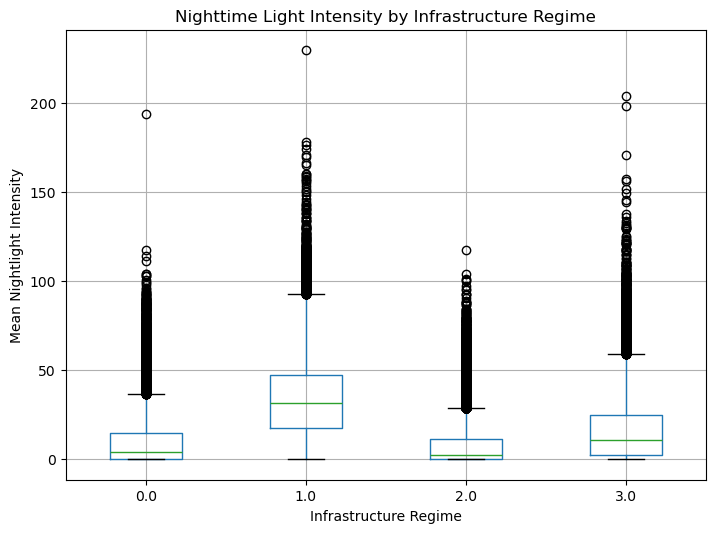

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

gdf.boxplot(
    column="nightlight_mean",
    by="infrastructure_regime",
    ax=ax
)

ax.set_title("Nighttime Light Intensity by Infrastructure Regime")
ax.set_xlabel("Infrastructure Regime")
ax.set_ylabel("Mean Nightlight Intensity")

plt.suptitle("")

plt.show()

The comparison revealed **clear economic differentiation** across mobility infrastructure regimes. Mean nightlight intensity ranged from **7.99** in Regime 2 to **33.97** in Regime 1, with the remaining regimes occupying intermediate positions. Regimes characterized by stronger and more stable mobility patterns were associated with higher nighttime luminosity, whereas weaker or less organized regimes corresponded to lower luminosity environments. These results provided **external validation** that the **Market Infrastructure Index (MII)** captured meaningful spatial variation in the conditions associated with local economic intensity.

# 8 Multiscale Infrastructure Reconstruction

## 8.1 Motivation for Downscaling

Although census tracts provided a useful administrative unit for national analysis, they often masked substantial spatial heterogeneity within their boundaries.

In large metropolitan regions, individual census tracts could contain multiple urban environments with very different levels of accessibility, mobility intensity, and economic activity. As a result, tract-level indicators could obscure fine-scale variation in the spatial conditions associated with market activity.

To examine this hidden spatial structure, we implemented a **mass-preserving downscaling** procedure that reconstructed a continuous infrastructure surface within census tracts while preserving the aggregate values observed at the tract level. This approach allowed us to evaluate how mobility-based infrastructure varied at a finer spatial scale and to identify **intra-tract fragmentation** not visible in aggregated tract-level data.

## 8.2 Study Area: São Paulo Metropolitan Region

To illustrate the multiscale structure of mobility infrastructure, we applied the downscaling procedure to the **São Paulo metropolitan region**.

São Paulo is one of the largest and most economically dynamic urban systems in the Southern Hemisphere. Its dense and heterogeneous urban landscape made it an appropriate setting for examining how mobility-based infrastructure varied within census tracts and how aggregated tract-level measures could conceal important intra-urban differentiation.

The downscaling analysis focused on reconstructing a **high-resolution infrastructure surface** for the São Paulo metropolitan region in order to reveal sub-tract spatial variation hidden within the original administrative units.

## 8.3 Mass-Preserving Spatial Downscaling

We implemented the spatial framework for a mass-preserving downscaling procedure designed to redistribute tract-level infrastructure values across a fine spatial grid while preserving aggregate tract-level quantities.

This step established the metropolitan extent, generated the high-resolution grid, and linked grid cells to the tract-level spatial structure required for the reconstruction stage.

In [ ]:
# ============================================================
# 8.3 Mass-Preserving Spatial Downscaling
# ============================================================

import geopandas as gpd
import numpy as np
from shapely.geometry import box

print("National tracts loaded:", len(gdf))
print("CRS:", gdf.crs)

# ------------------------------------------------------------
# Step 1 — Convert CRS to geographic
# ------------------------------------------------------------

gdf = gdf.to_crs(epsg=4326)

# ------------------------------------------------------------
# Step 2 — Select São Paulo metropolitan region
# ------------------------------------------------------------

print("\nSelecting São Paulo region...")

sp = gdf.cx[-47.2:-45.8, -24.2:-22.8].copy()

print("Tracts in São Paulo region:", len(sp))

# ------------------------------------------------------------
# Step 3 — Compute bounding box
# ------------------------------------------------------------

xmin, ymin, xmax, ymax = sp.total_bounds

print("\nBounding box:")
print(xmin, ymin, xmax, ymax)

# ------------------------------------------------------------
# Step 4 — Create high-resolution grid (~100m)
# ------------------------------------------------------------

grid_size = 0.001   # ≈ 100 meters

cols = np.arange(xmin, xmax, grid_size)
rows = np.arange(ymin, ymax, grid_size)

print("\nGrid columns:", len(cols))
print("Grid rows:", len(rows))

polygons = []

for x in cols:
    for y in rows:
        polygons.append(
            box(
                x,
                y,
                x + grid_size,
                y + grid_size
            )
        )

grid = gpd.GeoDataFrame(
    geometry=polygons,
    crs="EPSG:4326"
)

print("\nTotal grid cells:", len(grid))

# ------------------------------------------------------------
# Step 5 — Spatial join with census tracts
# ------------------------------------------------------------

print("\nAssigning infrastructure regimes to grid cells...")

grid = gpd.sjoin(
    grid,
    sp[["infrastructure_regime", "geometry"]],
    how="left",
    predicate="intersects"
)

print("Grid with regimes assigned:", len(grid))

# ------------------------------------------------------------
# Step 6 — Basic diagnostics
# ------------------------------------------------------------

print("\nGrid regime distribution:")

print(
    grid["infrastructure_regime"]
    .value_counts()
)

National tracts loaded: 468099
CRS: EPSG:4326

Selecting São Paulo region...
Tracts in São Paulo region: 61509

Bounding box:
-47.35736099999996 -24.27246879999994 -45.66622729999995 -22.734601099999956

Grid columns: 1692
Grid rows: 1538

Total grid cells: 2602296

Assigning infrastructure regimes to grid cells...
Grid with regimes assigned: 3262722

Grid regime distribution:
infrastructure_regime
1.0    1005529
3.0     392164
0.0     260130
2.0     129872
Name: count, dtype: int64


The preparatory downscaling step selected 61,509 census tracts in the São Paulo region and generated a fine-resolution grid with 2,602,296 cells, which expanded to 3,262,722 grid assignments after the spatial join. These steps established the spatial framework used in the subsequent reconstruction stage, in which tract-level infrastructure values were redistributed across the grid under aggregate-preserving constraints.

## 8.4 Reconstructed Infrastructure Surface

Using the tract-level and grid-level outputs produced by the mass-preserving reconstruction stage, we examined how mobility-based infrastructure varied within the São Paulo metropolitan region at 100-meter resolution. The objects gdf_tracts and gdf_grid contained, respectively, the original tract-level MII values and the reconstructed fine-scale intensity surface derived under aggregate-preserving constraints.

Rather than assigning a single value to each census tract, this reconstruction redistributed infrastructure intensity across a fine spatial grid while preserving tract-level totals. The resulting surface revealed spatial heterogeneity that remained hidden at the tract level.

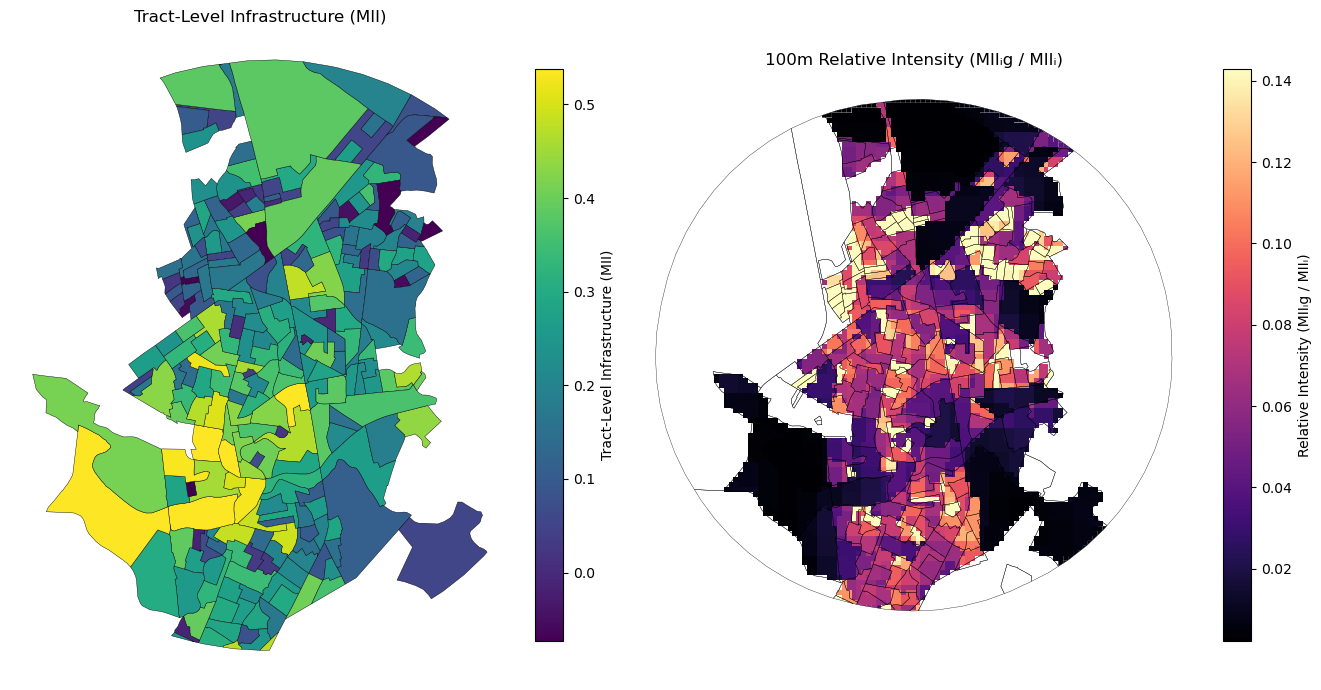

In [ ]:
# ============================================================
# 8.4 Reconstructed Infrastructure Surface (with colorbars)
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable

# ------------------------------------------------------------
# Prepare datasets
# ------------------------------------------------------------

gdf_grid = gdf_grid.copy()
gdf_tracts = gdf_tracts.copy()

# ------------------------------------------------------------
# Compute relative intensity
# ------------------------------------------------------------

gdf_grid["relative_intensity"] = (
    gdf_grid["mii_100m"] / gdf_grid["mii_tract"]
)

gdf_grid = gdf_grid.replace([np.inf, -np.inf], np.nan)
gdf_grid = gdf_grid.dropna(subset=["relative_intensity"]).copy()

# ------------------------------------------------------------
# Robust scaling
# ------------------------------------------------------------

low = np.nanpercentile(gdf_grid["relative_intensity"], 5)
high = np.nanpercentile(gdf_grid["relative_intensity"], 95)

vcenter = 1.0

if low < vcenter < high:
    norm_right = TwoSlopeNorm(vmin=low, vcenter=vcenter, vmax=high)
else:
    norm_right = Normalize(vmin=low, vmax=high)

vals_left = gdf_tracts["mii_tract"].astype(float)
vmin_left = np.nanpercentile(vals_left, 2)
vmax_left = np.nanpercentile(vals_left, 98)
norm_left = Normalize(vmin=vmin_left, vmax=vmax_left)

# ------------------------------------------------------------
# Colormaps
# ------------------------------------------------------------

cmap_left = plt.cm.viridis
cmap_right = plt.cm.magma.copy()
cmap_right.set_bad("black")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14,7))

# LEFT PANEL
gdf_tracts.plot(
    column="mii_tract",
    cmap=cmap_left,
    norm=norm_left,
    linewidth=0.3,
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Tract-Level Infrastructure (MII)")
axes[0].axis("off")

# RIGHT PANEL
gdf_grid.plot(
    column="relative_intensity",
    cmap=cmap_right,
    norm=norm_right,
    linewidth=0,
    ax=axes[1]
)

gdf_tracts.boundary.plot(
    ax=axes[1],
    linewidth=0.25,
    edgecolor="black"
)

axes[1].set_title("100m Relative Intensity (MIIᵢg / MIIᵢ)")
axes[1].axis("off")

# ------------------------------------------------------------
# Colorbars
# ------------------------------------------------------------

sm_left = ScalarMappable(norm=norm_left, cmap=cmap_left)
sm_left.set_array([])

sm_right = ScalarMappable(norm=norm_right, cmap=cmap_right)
sm_right.set_array([])

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

cbar_left.set_label("Tract-Level Infrastructure (MII)")

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

cbar_right.set_label("Relative Intensity (MIIᵢg / MIIᵢ)")

plt.tight_layout()
plt.show()

The reconstructed surface revealed **substantial spatial heterogeneity** within census tracts. While the tract-level representation assigned a single infrastructure value to each administrative unit, the downscaled surface exposed fine-scale variation in mobility-based infrastructure intensity across the urban landscape. High-intensity clusters appeared along major transportation corridors and dense commercial zones, while adjacent areas exhibited substantially lower relative intensities. By preserving tract-level totals while redistributing intensity across a fine spatial grid, the downscaling procedure made previously hidden **intra-tract fragmentation** empirically visible.

## 8.5 Intra-Tract Fragmentation

The downscaled infrastructure surface revealed that many census tracts contained substantial internal heterogeneity in **mobility-based market infrastructure**.

Rather than functioning as homogeneous spatial units, census tracts often contained multiple localized infrastructure environments that differed markedly in the intensity and organization of visitation activity.

This fragmentation was especially visible in large metropolitan areas, where commercial districts, transportation hubs, residential zones, and peripheral areas could coexist within the same administrative tract. These results showed that tract-level infrastructure measures should be interpreted as **aggregated representations of underlying spatial processes** rather than as homogeneous spatial environments. Recognizing this internal heterogeneity is critical for understanding how mobility infrastructure shapes local economic opportunity and market participation across urban space.

# 9 Discussion

This study showed that mobility intensity alone did not explain spatial variation in local economic intensity. Instead, the spatial organization of mobility interactions revealed a latent infrastructural layer that conditioned the feasibility of sustained market participation across space.

By extracting the dominant covariance structure among mobility indicators, the **Market Infrastructure Index (MII)** captured this latent structure and revealed substantial spatial heterogeneity across the national territory. Locations with similar mobility volumes frequently belonged to distinct infrastructural regimes, showing that the organization of visitation patterns played a critical role in shaping local economic environments.

The analysis of nighttime luminosity provided external validation for these regimes. Areas with stronger mobility infrastructure consistently corresponded to higher nighttime light intensity, indicating that mobility infrastructure closely aligned with the spatial organization of local economic intensity.

The multiscale reconstruction experiment in the São Paulo region further showed that census tracts often concealed substantial internal heterogeneity in infrastructure conditions. The downscaled surface revealed that infrastructure intensity varied continuously across space and frequently exhibited pronounced fragmentation within administrative boundaries.

Taken together, these findings underscore the importance of modeling spatial processes across multiple scales and show that mobility-based indicators can offer valuable insight into the spatial foundations of market systems.

# 10 Conclusion

This study introduced a spatial analytical framework to recover and reconstruct **mobility-based market infrastructure** from large-scale mobility data.

By deriving the **Market Infrastructure Index (MII)** from the covariance structure of visitation behavior, we showed that mobility infrastructure formed a spatially heterogeneous and multiscalar field rather than a uniform geography of movement.

The identification of infrastructure regimes demonstrated that locations with similar levels of mobility intensity could still exhibit fundamentally different structural conditions associated with economic interaction. External validation using **nighttime luminosity** confirmed that these regimes corresponded to distinct economic environments.

The multiscale downscaling experiment further showed that aggregated administrative units frequently concealed substantial internal variation in mobility-based infrastructure, highlighting the value of spatially explicit and scale-sensitive analytical approaches.

Taken together, these results contributed a **reproducible Spatial AI framework** for recovering latent spatial structure from mobility data and reconstructing fine-grained variation while preserving aggregate consistency. More broadly, the study opened new possibilities for examining the spatial foundations of economic systems and identifying the conditions under which markets emerge, persist, and differentiate across space.